In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image

image = Image.open("/content/drive/MyDrive/Sem6AI/eye.png")
image.show()

In [ ]:
# Convert image to NumPy Array
import numpy as np
from PIL import Image

image = Image.open("/content/drive/MyDrive/Sem6AI/eye.png")
image_array = np.array(image)

print(image_array.shape)

(836, 1258, 4)


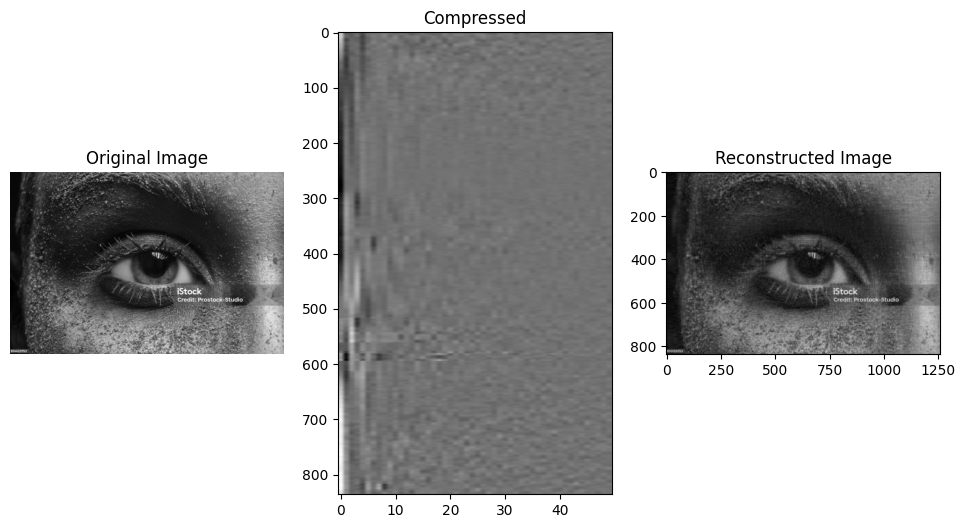

In [ ]:
# Image Compression
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
image = Image.open("/content/drive/MyDrive/Sem6AI/eye.png").convert("L")

# Convert to numpy array
image_array = np.array(image)

# Get dimensions
height, width = image_array.shape

# Step 1: reshape
data = image_array.reshape(height, width)

# Step 2: mean
mean = np.mean(data, axis=0)

# Step 3: center data
centered_data = data - mean

# Step 4: covariance
cov_matrix = np.cov(centered_data, rowvar=False)

# Step 5: eigenvalues & eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# sort eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, sorted_indices]

# choose k components
k = 50
components = eigenvectors[:, :k]

# Step 6: compression
compressed_data = np.dot(centered_data, components)

# Step 7: decompression
decompressed_data = np.dot(compressed_data, components.T) + mean

# Visualization
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title("Compressed")

plt.subplot(1,3,3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Reconstructed Image")

plt.show()

# Save reconstructed image
# reconstructed_image = Image.fromarray(np.uint8(decompressed_data))
# reconstructed_image.save("/content/compressed_image.png")

# # Download image
# from google.colab import files
# files.download('/content/compressed_image.png')